# Week 6 · Random Variables, Sampling Distributions, and the Central Limit Theorem

*DS 207 · Week 6*

This week connects probability to the decisions we make from samples. We treat delivery outcomes as random variables, describe their long-run behavior through expectation and variance, and then study how a statistic such as a sample mean varies from one sample to the next. The Central Limit Theorem explains why that variation is predictable even when the underlying data are strongly skewed, and simulation lets us watch it happen.

**Author:** EC Corro, built in collaboration with Claude, ChatGPT, and Gemini

## Learning Objectives

By the end of this notebook you will be able to:

- Classify random variables as discrete or continuous and match real delivery outcomes to the binomial and normal models.
- Compute and interpret the expectation and variance of a random variable by hand and with code, including linear transformations.
- Describe a sampling distribution and derive the mean and standard error of a sample mean and a sample proportion.
- State the Central Limit Theorem, its conditions, and the situations in which the normal approximation is slow to appear.
- Use simulation to verify sampling-distribution results and to choose an audit sample size.

**Prerequisites:** descriptive statistics and distribution shape (Weeks 1–2); basic probability rules such as complements and independence.

## Business Context

Visayas Fresh Logistics is a Cebu-based refrigerated delivery company that moves fresh produce, seafood, and vaccines for supermarkets, hospitals, and restaurants. Its client contracts promise that at least 95% of deliveries arrive within the promised window and that every box arrives at or below 5°C. Operations Director Liza Montecillo cannot inspect every delivery, so each week her team audits a random sample of 40 completed deliveries and reports the average transit time and the on-time rate.

Transit times are far from bell-shaped: most deliveries are quick, but traffic, port congestion, and road closures produce a long right tail. This notebook uses the ledger of 5,000 completed deliveries on the urban network (Metro Cebu and Mactan routes) as the complete population, so the true averages and rates are known and we can study exactly what sampling does to them.

**Stakeholder question:** If we audit 40 deliveries a week, how far can the audited average transit time drift from the true average before we should suspect a real service problem, and how likely is a week's on-time rate to dip below our contractual 95% by chance alone?

## Intuition & Analogy

*Subtopic 1 of 5 — Random variables and common distributions*

**Business hook.** Before Liza can judge any audit result, she needs to know which numbers an audit can produce and how likely each one is when nothing is wrong. That requires a model for the outcomes: the number of late deliveries in an audit, the temperature of a delivery box, and the minutes a delivery takes.

Think of every delivery as a lottery ticket. Before the draw, you do not know which ticket you will get. A **random variable** is the rule that reads a number off the ticket: "minutes in transit," "late (1) or not late (0)," "box temperature." Before the draw the number is uncertain; after the draw it is just data. The **distribution** of the random variable is the complete description of how likely each number is.

Random variables come in two kinds, and the difference is counting versus measuring.

- **Discrete:** the values can be listed, such as the number of late deliveries in an audit (0, 1, 2, ...). We can ask for the probability of exactly 3.
- **Continuous:** the values fill a range, such as transit minutes or temperature. The probability of exactly 45.000... minutes is zero, so we ask about ranges instead, such as the chance a delivery takes between 40 and 50 minutes.

Three shapes appear repeatedly in Liza's data.

- **Binomial (discrete).** Each audited delivery behaves like a flip of a biased coin that lands "late" about 4% of the time. The number of late deliveries in 40 flips is a binomial count.
- **Normal (continuous).** Box temperature is nudged up and down by many small independent influences: door openings, ambient heat, the age of the ice packs. Many small nudges add up to a bell shape.
- **Right-skewed (continuous).** Transit time has a floor set by the drive itself but no ceiling, and delays compound: one closed road adds a long stretch. The result is a bulk of quick deliveries with a long tail, not a bell.

## Theory — By Hand

**Definitions.** A random variable $X$ assigns a number to each outcome of a random process.

- Discrete: the probability mass function is $p(x) = P(X = x)$, with $\sum_x p(x) = 1$.
- Continuous: the probability density function $f(x) \ge 0$ satisfies $\int_{-\infty}^{\infty} f(x)\,dx = 1$, and probabilities are areas: $P(a \le X \le b) = \int_a^b f(x)\,dx$. The cumulative distribution function is $F(x) = P(X \le x)$.

**Binomial distribution.** If an audit checks $n$ deliveries, each independently late with probability $p$, the number of late deliveries $K$ follows $K \sim \text{Binomial}(n, p)$:

$$P(K = k) = \binom{n}{k} p^{k} (1-p)^{n-k}, \qquad k = 0, 1, \dots, n.$$

The four conditions are a fixed number of trials, two outcomes per trial, the same $p$ on every trial, and independent trials.

**Normal distribution.** $X \sim N(\mu, \sigma^2)$ has density

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).$$

Any normal probability reduces to the standard normal by standardizing: $Z = \dfrac{X - \mu}{\sigma} \sim N(0, 1)$.

**Worked example 1 — a mini-audit of $n = 4$ deliveries.** The ledger's late rate is 3.84%; rounded, $p = 0.04$. Let $K$ be the number of late deliveries among 4.

$$P(K = 0) = \binom{4}{0}(0.04)^0(0.96)^4 = 0.96^4 = 0.8493$$

$$P(K = 1) = \binom{4}{1}(0.04)^1(0.96)^3 = 4 \times 0.04 \times 0.884736 = 0.1416$$

$$P(K \ge 2) = 1 - P(K=0) - P(K=1) = 1 - 0.8493 - 0.1416 = 0.0091$$

A four-delivery audit finds two or more late deliveries less than 1% of the time when the true late rate is 4%.

**Worked example 2 — a temperature breach.** Box temperature is approximately normal with $\mu = 3.0\,^\circ\text{C}$ and $\sigma = 0.8\,^\circ\text{C}$. A breach is a reading above $5\,^\circ\text{C}$.

$$z = \frac{5 - 3.0}{0.8} = 2.50, \qquad P(X > 5) = 1 - \Phi(2.50) = 1 - 0.9938 = 0.0062$$

The standard normal table gives $\Phi(2.50) = 0.9938$, so about 6 in every 1,000 deliveries breach the limit.

## By Tool

The cells below rebuild the by-hand results at full scale on the 5,000-delivery urban ledger. The first cell loads the data; the second models the count of late deliveries in a 40-delivery audit; the third compares the continuous variables with their theoretical shapes.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_theme(style="whitegrid")

import numpy as np
import pandas as pd

# Delivery ledger for Visayas Fresh Logistics: one row per completed cold-chain delivery.
rng = np.random.default_rng(207)

routes = {
    # route: (deliveries, median transit minutes, log-scale sigma, promised window, mean box temp, sd box temp)
    "Metro Cebu":  (3200, 26, 0.46, 75, 3.0, 0.8),
    "Mactan":      (1800, 30, 0.50, 90, 3.1, 0.8),
    "North Cebu":  (1600, 40, 0.58, 120, 3.4, 0.9),
    "South Cebu":  (1400, 38, 0.56, 120, 3.3, 0.9),
}

frames = []
for name, (n, med, sig, promised, t_mu, t_sd) in routes.items():
    minutes = 15 + rng.lognormal(mean=np.log(med), sigma=sig, size=n)
    frames.append(pd.DataFrame({
        "route": name,
        "delivery_min": minutes.round(1),
        "promised_min": promised,
        "temp_c": rng.normal(t_mu, t_sd, size=n).round(2),
    }))

ledger = pd.concat(frames, ignore_index=True)
ledger.insert(0, "delivery_id", np.arange(1, len(ledger) + 1))
delay = ledger["delivery_min"] - ledger["promised_min"]
ledger["late"] = (delay > 0).astype(int)
ledger["penalty_php"] = np.select([delay > 30, delay > 0], [500, 200], default=0)

# Lecture window: the urban network (Metro Cebu and Mactan routes) is treated as the complete population
deliveries = ledger[ledger["route"].isin(["Metro Cebu", "Mactan"])].reset_index(drop=True)

times = deliveries["delivery_min"].to_numpy()
late = deliveries["late"].to_numpy()
temp = deliveries["temp_c"].to_numpy()
N = len(deliveries)

print(f"Population size: {N:,} deliveries")
deliveries.head()

Population size: 5,000 deliveries


,delivery_id,route,delivery_min,promised_min,temp_c,late,penalty_php
0,1,Metro Cebu,47.5,75,1.75,0,0
1,2,Metro Cebu,27.6,75,2.55,0,0
2,3,Metro Cebu,42.8,75,2.96,0,0
3,4,Metro Cebu,32.8,75,2.56,0,0
4,5,Metro Cebu,31.7,75,3.61,0,0


Population late rate p = 0.0384
 late_count  simulated_audits  binomial_pmf
          0            0.2054        0.2088
          1            0.3390        0.3336
          2            0.2608        0.2597
          3            0.1306        0.1314
          4            0.0467        0.0485
          5            0.0133        0.0140
          6            0.0034        0.0033
          7            0.0005        0.0006
          8            0.0003        0.0001

By-hand check, n = 4, p = 0.04
P(K=0) = 0.8493
P(K=1) = 0.1416
P(K>=2) = 0.0091


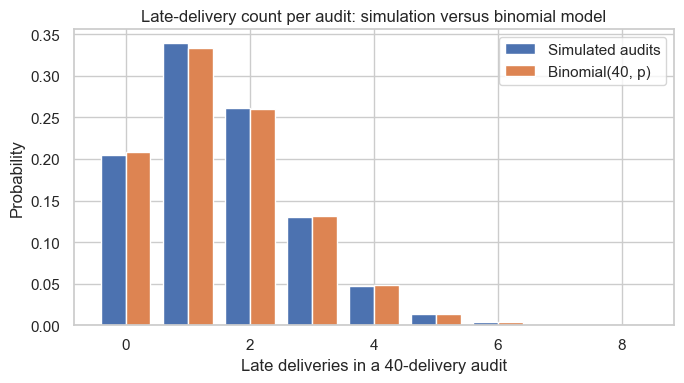

In [3]:
# Discrete random variable: number of late deliveries in a 40-delivery audit
rng = np.random.default_rng(207)
n_audit = 40
p_late = late.mean()

# 10,000 simulated weekly audits, each a random draw of 40 deliveries from the ledger
audits = rng.choice(late, size=(10_000, n_audit), replace=True)
late_counts = audits.sum(axis=1)

k = np.arange(0, 9)
comparison = pd.DataFrame({
    "late_count": k,
    "simulated_audits": [(late_counts == i).mean() for i in k],
    "binomial_pmf": stats.binom.pmf(k, n_audit, p_late),
})
print(f"Population late rate p = {p_late:.4f}")
print(comparison.to_string(index=False, float_format="{:.4f}".format))

# Verify the by-hand mini-audit (n = 4, p = 0.04)
print("\nBy-hand check, n = 4, p = 0.04")
print("P(K=0) =", round(stats.binom.pmf(0, 4, 0.04), 4))
print("P(K=1) =", round(stats.binom.pmf(1, 4, 0.04), 4))
print("P(K>=2) =", round(stats.binom.sf(1, 4, 0.04), 4))

fig, ax = plt.subplots(figsize=(7, 4))
width = 0.4
ax.bar(k - width / 2, comparison["simulated_audits"], width, label="Simulated audits")
ax.bar(k + width / 2, comparison["binomial_pmf"], width, label="Binomial(40, p)")
ax.set_xlabel("Late deliveries in a 40-delivery audit")
ax.set_ylabel("Probability")
ax.set_title("Late-delivery count per audit: simulation versus binomial model")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the results.** The simulated audits and the binomial probabilities agree to within simulation noise, so the binomial model is a sound description of the weekly late count. The distribution is right-skewed and concentrated on small values: with $n = 40$ and $p =$ 0.0384, the expected count is only 1.54 late deliveries, so a count of 0, 1, or 2 is routine and a count of 5 or more is rare. The by-hand mini-audit values ($0.8493$, $0.1416$, $0.0091$) are reproduced by `scipy.stats.binom`.

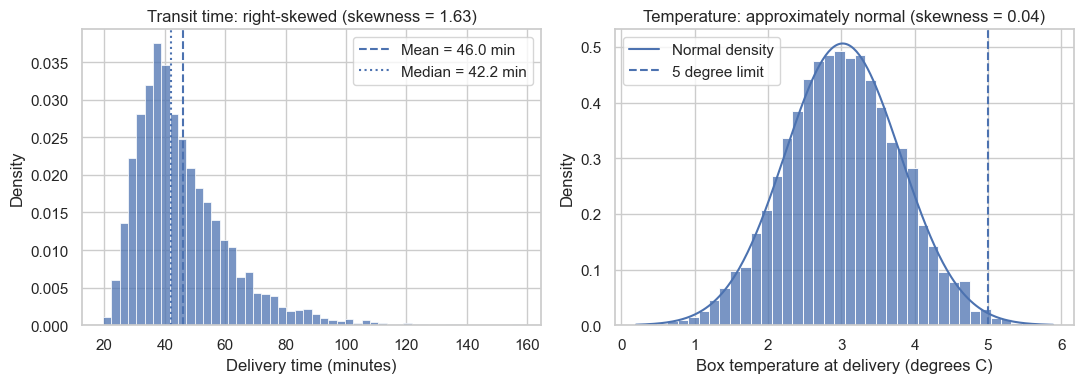

Observed breach rate:  0.0064
Normal-model estimate: 0.0060
By-hand estimate (mu = 3.0, sigma = 0.8): 0.0062

Share of deliveries over 60 minutes: 0.1566


In [4]:
# Continuous random variables: transit time (right-skewed) and box temperature (bell-shaped)
temp_mu, temp_sd = temp.mean(), temp.std(ddof=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(times, bins=50, stat="density", ax=axes[0])
axes[0].axvline(times.mean(), linestyle="--", label=f"Mean = {times.mean():.1f} min")
axes[0].axvline(np.median(times), linestyle=":", label=f"Median = {np.median(times):.1f} min")
axes[0].set_xlabel("Delivery time (minutes)")
axes[0].set_title(f"Transit time: right-skewed (skewness = {stats.skew(times):.2f})")
axes[0].legend()

sns.histplot(temp, bins=40, stat="density", ax=axes[1])
grid = np.linspace(temp.min(), temp.max(), 300)
axes[1].plot(grid, stats.norm.pdf(grid, temp_mu, temp_sd), label="Normal density")
axes[1].axvline(5, linestyle="--", label="5 degree limit")
axes[1].set_xlabel("Box temperature at delivery (degrees C)")
axes[1].set_title(f"Temperature: approximately normal (skewness = {stats.skew(temp):.2f})")
axes[1].legend()
plt.tight_layout()
plt.show()

# Probability of a temperature breach: observed frequency versus the normal model
emp_breach = (temp > 5).mean()
norm_breach = stats.norm.sf(5, temp_mu, temp_sd)
print(f"Observed breach rate:  {emp_breach:.4f}")
print(f"Normal-model estimate: {norm_breach:.4f}")
print(f"By-hand estimate (mu = 3.0, sigma = 0.8): {stats.norm.sf(2.5):.4f}")

# Probability that a single delivery takes longer than 60 minutes: model-free frequency
print(f"\nShare of deliveries over 60 minutes: {(times > 60).mean():.4f}")

**Reading the results.** Temperature follows the bell curve closely, so the normal model predicts the breach rate of 0.0060 against the observed 0.0064. Transit time does not: the mean (46.0 minutes) sits above the median (42.2 minutes) and the skewness is 1.63. A normal model fitted to these times would misstate the long-delay tail, which is why later sections study the *average* of many deliveries rather than a single one.

## Business Application

Liza can now translate raw audit results into a statement about chance. Two findings feed her weekly review.

- **Late-delivery counts.** With a true late rate of 3.8%, an audit of 40 deliveries shows three or more late deliveries in 19.8% of weeks purely by chance. Her team should treat a count of 0 to 2 as normal variation and reserve investigation for counts that the binomial model says are unusual.
- **Temperature breaches.** About 6 in every 1,000 deliveries exceed 5°C, and the normal model reproduces that rate. The Quality Manager can use the same model to price the effect of a slightly warmer fleet: each small rise in the average box temperature moves the breach rate through the upper tail, which the normal model quantifies before any contract is put at risk.

## Intuition & Analogy

*Subtopic 2 of 5 — Expectation and variance of a random variable*

**Business hook.** Liza's finance team asks two questions every quarter: what does a delivery cost us in service-level penalties on average, and how unpredictable will the penalty bill be from one batch to the next?

**Expectation** is the long-run average: the balance point of the distribution. Picture a seesaw with a weight at every possible outcome, each weight equal to that outcome's probability; the expectation is where the seesaw balances. It is also what a carnival game's operator uses to price a game: nobody predicts any single play, but the average payout over thousands of plays is stable and knowable.

**Variance** measures how far outcomes typically fall from that balance point. Two games can pay the same on average and feel completely different: one pays ₱10 every time, the other pays ₱0 almost always and ₱500 now and then. The averages match; the variances do not. The standard deviation is the square root of the variance, which returns the measure to the original units (pesos, minutes, degrees).

Penalties are a natural example. Most deliveries cost nothing. A few late ones cost ₱200, and the rare very late one costs ₱500. The expectation tells finance what to budget per delivery; the variance tells them how much cushion the budget needs.

## Theory — By Hand

**Expectation.**

$$E[X] = \sum_x x\,p(x) \quad \text{(discrete)}, \qquad E[X] = \int_{-\infty}^{\infty} x f(x)\,dx \quad \text{(continuous)}.$$

**Variance and standard deviation.**

$$\operatorname{Var}(X) = E\big[(X-\mu)^2\big] = E[X^2] - \big(E[X]\big)^2, \qquad \operatorname{SD}(X) = \sqrt{\operatorname{Var}(X)}.$$

**Linear transformations.** For constants $a$ and $b$:

$$E[aX + b] = aE[X] + b, \qquad \operatorname{Var}(aX + b) = a^2 \operatorname{Var}(X).$$

**Sums of independent variables.** If $X_1, \dots, X_n$ are independent with the same mean $\mu$ and variance $\sigma^2$, then

$$E\!\left[\sum_{i=1}^n X_i\right] = n\mu, \qquad \operatorname{Var}\!\left(\sum_{i=1}^n X_i\right) = n\sigma^2.$$

**Binomial moments.** Because a binomial count is a sum of $n$ independent Bernoulli variables, $E[K] = np$ and $\operatorname{Var}(K) = np(1-p)$.

**Worked example 1 — penalty per delivery.** Let $X$ be the penalty in pesos, with the probabilities below (taken from the ledger and rounded to four decimals).

| Penalty $x$ | ₱0 (on time) | ₱200 (up to 30 min late) | ₱500 (over 30 min late) |
|---|---|---|---|
| $p(x)$ | 0.9616 | 0.0326 | 0.0058 |

$$E[X] = 0(0.9616) + 200(0.0326) + 500(0.0058) = 6.52 + 2.90 = 9.42 \text{ pesos}$$

$$E[X^2] = 200^2(0.0326) + 500^2(0.0058) = 1304 + 1450 = 2754$$

$$\operatorname{Var}(X) = 2754 - (9.42)^2 = 2665.26, \qquad \operatorname{SD}(X) = \sqrt{2665.26} = 51.63 \text{ pesos}$$

The standard deviation (about ₱52) is more than five times the mean (₱9.42): penalties are rare but lumpy.

**Worked example 2 — a 40-delivery audit.** Treating the 40 deliveries as independent, the total penalty $T$ has

$$E[T] = 40 \times 9.42 = 376.80, \qquad \operatorname{Var}(T) = 40 \times 2665.26 = 106610.5, \qquad \operatorname{SD}(T) = 326.5.$$

The mean grows in proportion to $n$, but the standard deviation grows only with $\sqrt{n}$, so the total is relatively less variable per delivery as the batch gets larger.

**Worked example 3 — a linear cost.** Suppose fuel and driver cost per delivery is $C = 12 + 1.5M$ pesos, where $M$ is transit minutes with $E[M] = 46.01$ and $\operatorname{SD}(M) = 16.05$.

$$E[C] = 12 + 1.5(46.01) = 81.02, \qquad \operatorname{SD}(C) = 1.5 \times 16.05 = 24.07.$$

The constant 12 shifts the mean but does not change the spread; the multiplier 1.5 scales both.

penalty_php
0     0.9616
200   0.0326
500   0.0058

E[X]   = 9.42  (data mean: 9.42)
Var(X) = 2665.26  (data variance: 2665.26)
SD(X)  = 51.63

Audit total, formula:    mean = 376.80, SD = 326.51
Audit total, simulated:  mean = 377.17, SD = 325.67

E[C]  formula = 81.02, data = 81.02
SD(C) formula = 24.07, data = 24.07

Late count per audit: np = 1.536 vs simulated mean 1.532
Late count per audit: np(1-p) = 1.477 vs simulated variance 1.456


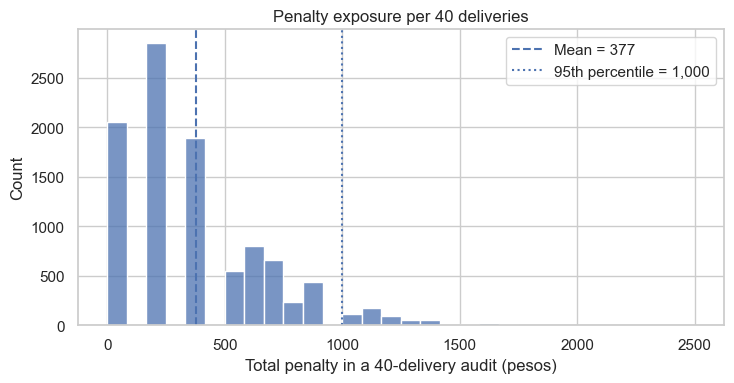

In [5]:
# Expectation and variance of the penalty random variable
pmf = deliveries["penalty_php"].value_counts(normalize=True).sort_index()
x_vals = pmf.index.to_numpy(dtype=float)
p_vals = pmf.to_numpy()

E_pen = np.sum(x_vals * p_vals)
E_pen_sq = np.sum(x_vals**2 * p_vals)
var_pen = E_pen_sq - E_pen**2
sd_pen = np.sqrt(var_pen)

print(pmf.rename("probability").to_string(float_format="{:.4f}".format))
print(f"\nE[X]   = {E_pen:.2f}  (data mean: {deliveries['penalty_php'].mean():.2f})")
print(f"Var(X) = {var_pen:.2f}  (data variance: {deliveries['penalty_php'].var(ddof=0):.2f})")
print(f"SD(X)  = {sd_pen:.2f}")

# Sum of 40 independent deliveries: formula versus simulated audits
rng = np.random.default_rng(207)
penalties = deliveries["penalty_php"].to_numpy()
audit_totals = rng.choice(penalties, size=(10_000, 40), replace=True).sum(axis=1)
print(f"\nAudit total, formula:    mean = {40 * E_pen:.2f}, SD = {np.sqrt(40 * var_pen):.2f}")
print(f"Audit total, simulated:  mean = {audit_totals.mean():.2f}, SD = {audit_totals.std():.2f}")

# Linear transformation: cost per delivery = 12 + 1.5 * minutes
mu, sigma = times.mean(), times.std(ddof=0)
cost = 12 + 1.5 * times
print(f"\nE[C]  formula = {12 + 1.5 * mu:.2f}, data = {cost.mean():.2f}")
print(f"SD(C) formula = {1.5 * sigma:.2f}, data = {cost.std(ddof=0):.2f}")

# Binomial moments: np and np(1 - p) versus the simulated late counts
print(f"\nLate count per audit: np = {40 * p_late:.3f} vs simulated mean {late_counts.mean():.3f}")
print(f"Late count per audit: np(1-p) = {40 * p_late * (1 - p_late):.3f} vs simulated variance {late_counts.var():.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(audit_totals, bins=30, ax=ax)
ax.axvline(audit_totals.mean(), linestyle="--", label=f"Mean = {audit_totals.mean():,.0f}")
ax.axvline(np.percentile(audit_totals, 95), linestyle=":", label=f"95th percentile = {np.percentile(audit_totals, 95):,.0f}")
ax.set_xlabel("Total penalty in a 40-delivery audit (pesos)")
ax.set_title("Penalty exposure per 40 deliveries")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the results.** The hand-computed expectation, variance, and standard deviation match the ledger exactly, the simulated audit totals reproduce the $n\mu$ and $\sqrt{n}\,\sigma$ formulas, and the linear-cost and binomial-moment rules hold to the printed precision. The histogram shows why the mean alone is not enough: about 21% of audits incur no penalty at all, yet the 95th percentile of the audit total is ₱1,000, far above the expected ₱377.

## Business Application

Liza's finance partner uses the expectation to set the standing penalty provision and the variance to size the reserve above it.

- **Provision.** The expected penalty is ₱9.42 per delivery, or ₱9,420 per 1,000 deliveries. This is the amount to budget as a routine cost of service.
- **Reserve.** Because the standard deviation of a 40-delivery batch (₱327) is nearly as large as its mean (₱377), a budget set at the mean would be exceeded in roughly 51% of audit batches. The 95th percentile of ₱1,000 is a defensible ceiling for a batch-level alert.
- **Pricing.** The cost model $C = 12 + 1.5M$ shows the Operations Director that trimming the average transit time by one minute lowers expected cost by ₱1.50 per delivery, while reducing variability (the standard deviation of $M$) lowers cost volatility one-for-one with the multiplier.

## Intuition & Analogy

*Subtopic 3 of 5 — Sampling distributions*

**Business hook.** Each Monday Liza receives one number: the average transit time of that week's 40 audited deliveries. Next Monday the number will be different even if nothing about the service has changed. Her question is how much of that movement is just the luck of which deliveries were drawn.

Think of tasting a large pot of soup with a spoon. Every spoonful tastes slightly different, yet the pot itself has one fixed flavor. The flavor of the pot is a **parameter**, such as the true average transit time $\mu$. The flavor of one spoonful is a **statistic**, such as the audit's sample mean $\bar{X}$. If you could taste thousands of spoonfuls and record each one, the spread of those recorded values would show how far a single spoonful is likely to stray. That collection of possible statistic values, with their probabilities, is the **sampling distribution**.

Two ideas make sampling distributions useful.

- **The statistic is itself a random variable.** Which 40 deliveries land in the audit is random, so the audit average is random, and it has its own mean, variance, and shape.
- **Averages are steadier than individuals.** A single 3-hour delivery is startling; among 40 deliveries it is one voice in a crowd. Averaging cancels part of the randomness, and the more deliveries in the audit, the more it cancels.

## Theory — By Hand

Let $X_1, \dots, X_n$ be a random sample from a population with mean $\mu$ and standard deviation $\sigma$, and let $\bar{X} = \frac{1}{n}\sum_{i=1}^n X_i$.

**Mean of the sample mean.** By linearity of expectation,

$$E[\bar{X}] = \mu.$$

The sample mean is *unbiased*: its average over all possible samples is the population mean.

**Variance and standard error of the sample mean.** For independent observations,

$$\operatorname{Var}(\bar{X}) = \frac{\sigma^2}{n}, \qquad \operatorname{SE}(\bar{X}) = \frac{\sigma}{\sqrt{n}}.$$

The standard deviation of a statistic is called its **standard error**. Quadrupling the sample size halves it.

**Sample proportion.** If $\hat{p}$ is the proportion of late deliveries in an audit of $n$,

$$E[\hat{p}] = p, \qquad \operatorname{SE}(\hat{p}) = \sqrt{\frac{p(1-p)}{n}}.$$

**Finite population.** When the sample is a sizeable fraction of a small population and drawn without replacement, the standard error is multiplied by $\sqrt{(N-n)/(N-1)}$. When $n$ is small relative to $N$, this factor is close to 1 and can be ignored.

**Worked example — the sampling distribution, enumerated.** A tiny population has four delivery times: 25, 35, 45, and 95 minutes. Its mean and variance are

$$\mu = \frac{25 + 35 + 45 + 95}{4} = 50, \qquad \sigma^2 = \frac{(25-50)^2 + (35-50)^2 + (45-50)^2 + (95-50)^2}{4} = \frac{625 + 225 + 25 + 2025}{4} = 725.$$

Draw samples of size $n = 2$ with replacement. There are $4 \times 4 = 16$ equally likely ordered samples, and each has a sample mean. Listing all 16 gives the sampling distribution of $\bar{X}$:

| Sample mean $\bar{x}$ | 25 | 30 | 35 | 40 | 45 | 60 | 65 | 70 | 95 |
|---|---|---|---|---|---|---|---|---|---|
| Number of samples | 1 | 2 | 3 | 2 | 1 | 2 | 2 | 2 | 1 |
| Probability | 1/16 | 2/16 | 3/16 | 2/16 | 1/16 | 2/16 | 2/16 | 2/16 | 1/16 |

For example, $\bar{x} = 60$ arises from the ordered samples (25, 95) and (95, 25). The mean of the sampling distribution is

$$E[\bar{X}] = \frac{25 + 2(30) + 3(35) + 2(40) + 45 + 2(60) + 2(65) + 2(70) + 95}{16} = \frac{800}{16} = 50 = \mu.$$

Its variance is

$$\operatorname{Var}(\bar{X}) = \frac{625 + 2(400) + 3(225) + 2(100) + 25 + 2(100) + 2(225) + 2(400) + 2025}{16} = \frac{5800}{16} = 362.5 = \frac{\sigma^2}{n} = \frac{725}{2}.$$

Both formulas hold exactly. The standard error is $\sqrt{362.5} = 19.04$ minutes, compared with a population standard deviation of $\sqrt{725} = 26.93$ minutes. Notice also that the population is lopsided because of the 95-minute delivery, yet the sampling distribution has already begun to spread across more values.

## By Tool

The first cell reproduces the enumeration. The next cells scale up to the full ledger and confirm the mean, the standard error, and the effect of the audit size.

In [6]:
from itertools import product

# Reproduce the by-hand enumeration: all 16 ordered samples of size 2 from four delivery times
tiny = np.array([25, 35, 45, 95])
pair_means = np.array([np.mean(pair) for pair in product(tiny, repeat=2)])
tiny_dist = pd.Series(pair_means).value_counts().sort_index()

print(pd.DataFrame({
    "sample_mean": tiny_dist.index.astype(int),
    "count": tiny_dist.to_numpy(),
    "probability": tiny_dist.to_numpy() / 16,
}).to_string(index=False, float_format="{:.4f}".format))

print(f"\nPopulation mean {tiny.mean():.1f}, population variance {tiny.var():.1f}")
print(f"Mean of sample means {pair_means.mean():.1f}")
print(f"Variance of sample means {pair_means.var():.2f}  (sigma^2 / n = {tiny.var() / 2:.2f})")

 sample_mean  count  probability
          25      1       0.0625
          30      2       0.1250
          35      3       0.1875
          40      2       0.1250
          45      1       0.0625
          60      2       0.1250
          65      2       0.1250
          70      2       0.1250
          95      1       0.0625

Population mean 50.0, population variance 725.0
Mean of sample means 50.0
Variance of sample means 362.50  (sigma^2 / n = 362.50)


Population mean mu = 46.011, population SD sigma = 16.045
Mean of the 10,000 audit averages:  45.996
SD of the 10,000 audit averages:    2.532
Theoretical SE = sigma / sqrt(n):   2.537
Finite-population factor for n = 40 out of N = 5,000: 0.9961


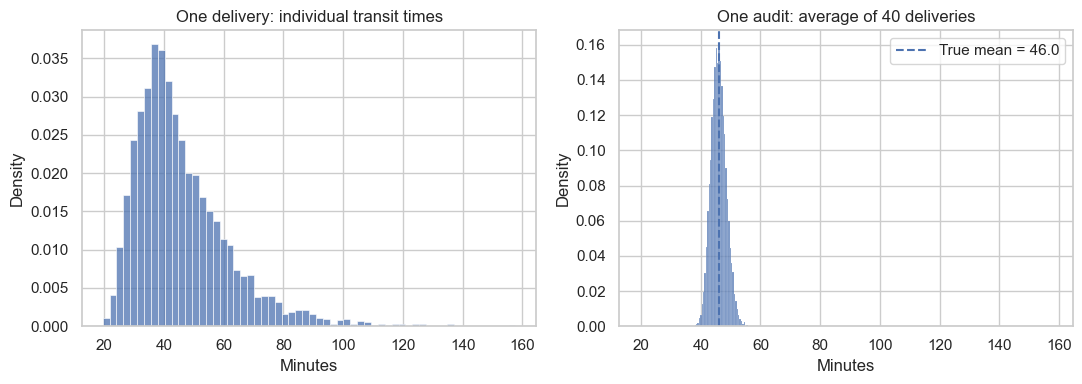

In [7]:
# Full scale: 10,000 weekly audits of n = 40 deliveries from the urban ledger
rng = np.random.default_rng(207)
n = 40
mu, sigma = times.mean(), times.std(ddof=0)

sample_means = rng.choice(times, size=(10_000, n), replace=True).mean(axis=1)

se_theory = sigma / np.sqrt(n)
fpc = np.sqrt((N - n) / (N - 1))

print(f"Population mean mu = {mu:.3f}, population SD sigma = {sigma:.3f}")
print(f"Mean of the 10,000 audit averages:  {sample_means.mean():.3f}")
print(f"SD of the 10,000 audit averages:    {sample_means.std():.3f}")
print(f"Theoretical SE = sigma / sqrt(n):   {se_theory:.3f}")
print(f"Finite-population factor for n = 40 out of N = {N:,}: {fpc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
sns.histplot(times, bins=60, stat="density", ax=axes[0])
axes[0].set_title("One delivery: individual transit times")
axes[0].set_xlabel("Minutes")
sns.histplot(sample_means, bins=40, stat="density", ax=axes[1])
axes[1].axvline(mu, linestyle="--", label=f"True mean = {mu:.1f}")
axes[1].set_title("One audit: average of 40 deliveries")
axes[1].set_xlabel("Minutes")
axes[1].legend()
plt.tight_layout()
plt.show()

 audit_size  simulated_SE  theoretical_SE
          5         7.204           7.176
         10         5.057           5.074
         20         3.534           3.588
         40         2.550           2.537
         80         1.795           1.794
        160         1.266           1.269


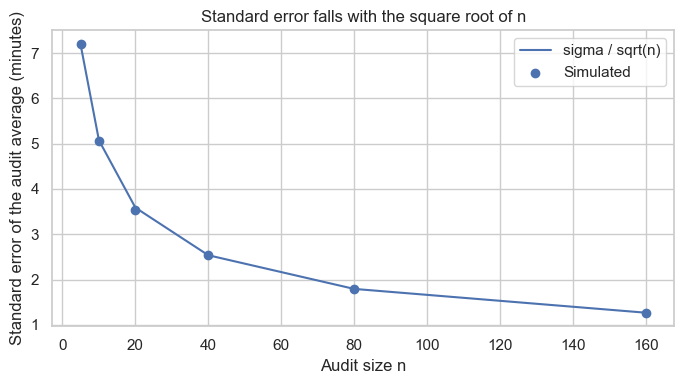


Sample proportion late: mean = 0.0383 (p = 0.0384)
Sample proportion late: SD   = 0.0302 (sqrt(p(1-p)/n) = 0.0304)


In [8]:
# How the standard error shrinks as the audit grows
sizes = np.array([5, 10, 20, 40, 80, 160])
rng = np.random.default_rng(207)
se_sim = np.array([
    rng.choice(times, size=(5_000, m), replace=True).mean(axis=1).std() for m in sizes
])
se_th = sigma / np.sqrt(sizes)

print(pd.DataFrame({"audit_size": sizes, "simulated_SE": se_sim, "theoretical_SE": se_th})
      .to_string(index=False, float_format="{:.3f}".format))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, se_th, label="sigma / sqrt(n)")
ax.scatter(sizes, se_sim, label="Simulated", zorder=3)
ax.set_xlabel("Audit size n")
ax.set_ylabel("Standard error of the audit average (minutes)")
ax.set_title("Standard error falls with the square root of n")
ax.legend()
plt.tight_layout()
plt.show()

# Sample proportion of late deliveries (audits of 40 from the earlier simulation)
p_hat = late_counts / 40
print(f"\nSample proportion late: mean = {p_hat.mean():.4f} (p = {p_late:.4f})")
print(f"Sample proportion late: SD   = {p_hat.std():.4f} (sqrt(p(1-p)/n) = {np.sqrt(p_late * (1 - p_late) / 40):.4f})")

**Reading the results.** The enumeration reproduces the hand table exactly. On the full ledger, the average of the 10,000 audit averages (46.00) sits on the true mean (46.01), confirming that the sample mean is unbiased. The standard deviation of the audit averages (2.532) matches $\sigma/\sqrt{n} =$ 2.537; the finite-population factor of 0.9961 is negligible at this audit size. Individual deliveries range from 20 to 158 minutes, while audit averages stay within a narrow band around the true mean. The table confirms the square-root law: moving from 40 to 160 deliveries halves the standard error. The sample proportion of late deliveries behaves the same way, with its spread matching $\sqrt{p(1-p)/n}$.

## Business Application

Liza now has the first half of her answer: a benchmark for how far a weekly audit average can wander without any change in service.

- **Normal weekly wobble.** With $\operatorname{SE} =$ 2.54 minutes, an audit average will typically land within about ±5.1 minutes (two standard errors) of the true average of 46.0 minutes. A week that reads 48.5 or 43.5 is nothing to escalate.
- **Cost of precision.** Halving that wobble requires four times the audit effort (160 deliveries a week instead of 40). The Operations Director can weigh the cost of auditing labor against how tight a signal she needs.
- **Late-rate audits are noisier.** The standard error of the weekly late rate at $n = 40$ is 3.0 percentage points, about 79% of the late rate itself, so single-week late rates should not drive staffing decisions.

## Intuition & Analogy

*Subtopic 4 of 5 — The Central Limit Theorem*

**Business hook.** Individual transit times are strongly skewed, yet Liza's team reports a margin of error built from a bell curve. Why is that legitimate, and when would it not be?

Roll one die and every face is equally likely: a flat picture. Add two dice and the totals pile up around 7 in a triangle. Add ten dice and the totals form a smooth bell, even though each die on its own is nothing like a bell. Adding or averaging many independent random pieces smooths out the quirks of the individual pieces, because unusually high and unusually low pieces tend to offset one another.

The same thing happens to delivery times. One very late delivery is a large surprise on its own, but inside an average of 40 deliveries it is diluted by 39 ordinary ones. Across many audits, sometimes a few extra late deliveries push the average up and sometimes a few extra fast ones pull it down, and the outcomes arrange themselves in a bell shape around the true mean. The **Central Limit Theorem (CLT)** makes this precise: the average of many independent observations is approximately normal, whatever the shape of the individual observations, provided the variance is finite.

The theorem does not say the data become normal. The individual deliveries stay skewed forever. It says the *sampling distribution of the average* becomes normal, which is exactly the object Liza's margin of error depends on.

## Theory — By Hand

**Statement.** Let $X_1, \dots, X_n$ be independent and identically distributed with mean $\mu$ and finite variance $\sigma^2$. Then, as $n$ grows,

$$Z_n = \frac{\bar{X} - \mu}{\sigma/\sqrt{n}} \;\xrightarrow{d}\; N(0, 1), \qquad \text{so that} \qquad \bar{X} \;\approx\; N\!\left(\mu, \frac{\sigma^2}{n}\right).$$

**How large must $n$ be?** The theorem is a limit statement, so the useful question is how quickly it takes hold.

- The more skewed or heavy-tailed the data, the larger $n$ must be. The common guideline of $n \ge 30$ is adequate for moderate skew and too small for extreme skew.
- For a proportion, the normal approximation to the binomial is reliable when both $np \ge 10$ and $n(1-p) \ge 10$.
- The skewness of the sample mean shrinks like $1/\sqrt{n}$: $\text{skew}(\bar{X}) = \text{skew}(X)/\sqrt{n}$.

**Confidence interval for the mean.** An approximate 95% interval for $\mu$ from one audit is

$$\bar{x} \pm 1.96\,\frac{s}{\sqrt{n}}.$$

**Worked example — the chance an audit average exceeds 50 minutes.** For the urban network, $\mu = 46.01$ and $\sigma = 16.05$. For an audit of $n = 40$:

$$\operatorname{SE} = \frac{16.05}{\sqrt{40}} = \frac{16.05}{6.325} = 2.538$$

$$z = \frac{50 - 46.01}{2.538} = 1.57, \qquad P(\bar{X} > 50) \approx 1 - \Phi(1.57) = 1 - 0.9418 = 0.0582.$$

A weekly average above 50 minutes therefore occurs about 5.8% of the time by chance alone. The 95% margin of error for the audit average is

$$1.96 \times 2.538 = 4.97 \text{ minutes.}$$

Compare this with a single delivery: the chance that one delivery exceeds 50 minutes is far larger, because the individual spread is $\sigma = 16.05$, not $2.54$.

## By Tool

The cells below test the normal calculation against 20,000 simulated audits, check how well the 95% interval performs, inspect normality with a QQ plot, and show where the approximation breaks down for a proportion.

In [9]:
# CLT calculation versus simulation: P(audit average > 50 minutes), n = 40
n = 40
threshold = 50
se = sigma / np.sqrt(n)
z = (threshold - mu) / se
p_clt = stats.norm.sf(z)

rng = np.random.default_rng(207)
samples = rng.choice(times, size=(20_000, n), replace=True)
means_40 = samples.mean(axis=1)

p_sim = (means_40 > threshold).mean()
p_single = (times > threshold).mean()

print(f"SE = {se:.3f}, z = {z:.3f}")
print(f"CLT (normal) probability that an audit average exceeds {threshold}: {p_clt:.4f}")
print(f"Simulated probability from 20,000 audits:                  {p_sim:.4f}")
print(f"Probability a single delivery exceeds {threshold} minutes:          {p_single:.4f}")

# Coverage of the approximate 95% interval built from each audit's own mean and SD
s = samples.std(axis=1, ddof=1)
margin = 1.96 * s / np.sqrt(n)
coverage = ((means_40 - margin <= mu) & (mu <= means_40 + margin)).mean()
print(f"\nCoverage of the 95% interval across 20,000 audits: {coverage:.4f}")

SE = 2.537, z = 1.572
CLT (normal) probability that an audit average exceeds 50: 0.0580
Simulated probability from 20,000 audits:                  0.0660
Probability a single delivery exceeds 50 minutes:          0.3098

Coverage of the 95% interval across 20,000 audits: 0.9329


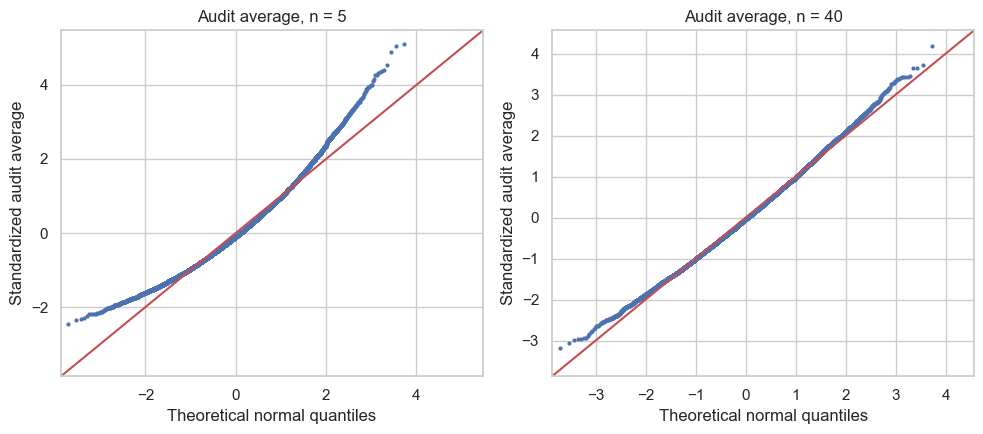

In [10]:
# QQ plots of standardized audit averages against the normal distribution
def standardized_means(m, reps=10_000, seed=207):
    r = np.random.default_rng(seed)
    x = r.choice(times, size=(reps, m), replace=True).mean(axis=1)
    return (x - mu) / (sigma / np.sqrt(m))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, m in zip(axes, [5, 40]):
    sm.qqplot(standardized_means(m), line="45", ax=ax, markersize=2)
    ax.set_title(f"Audit average, n = {m}")
    ax.set_xlabel("Theoretical normal quantiles")
    ax.set_ylabel("Standardized audit average")
plt.tight_layout()
plt.show()

In [11]:
# Where the CLT is slow: the on-time rate for small audits
# The on-time rate falls below 95% when more than 5% of the audited deliveries are late
rows = []
for m in [40, 160, 400, 1000]:
    k_min = m // 20 + 1                                   # smallest late count above 5% of m
    exact = stats.binom.sf(k_min - 1, m, p_late)          # exact binomial P(K >= k_min)
    mean_k, sd_k = m * p_late, np.sqrt(m * p_late * (1 - p_late))
    approx = stats.norm.sf((k_min - 0.5 - mean_k) / sd_k) # normal approximation with continuity correction
    rows.append({"audit_size": m, "np": mean_k, "late_count_needed": k_min,
                 "exact_binomial": exact, "normal_approx": approx})

clt_table = pd.DataFrame(rows)
print(clt_table.to_string(index=False, float_format="{:.4f}".format))

 audit_size      np  late_count_needed  exact_binomial  normal_approx
         40  1.5360                  3          0.1979         0.2138
        160  6.1440                  9          0.1640         0.1662
        400 15.3600                 21          0.0947         0.0905
       1000 38.4000                 51          0.0270         0.0232


**Reading the results.** The normal calculation gives 0.0580 and the simulation gives 0.0660 for the chance that a 40-delivery audit averages more than 50 minutes. The two are close even though the underlying times are skewed, and the small gap runs in the expected direction: the audit averages retain a trace of right skew (about 0.25 at $n = 40$), so the true upper tail is slightly heavier than the normal curve suggests. A single delivery exceeds 50 minutes far more often (0.3098), which shows how much steadier the average is than any one observation. The 95% interval captured the true mean in 93.3% of audits, slightly below the nominal 95% because the data are skewed and $n = 40$ is modest. In the QQ plots, the $n = 5$ averages bend away from the reference line in the upper tail, while the $n = 40$ averages track it closely, with only a slight lift in the far upper tail.

The proportion table is the cautionary tale. At $n = 40$ the expected late count is only 1.54, well below the guideline of 10, and the normal approximation to the chance of a sub-95% week (0.2138) is noticeably off from the exact binomial value (0.1979), because the exact distribution is discrete and lopsided at such small counts. The gap narrows as $np$ grows past 10. Use the exact binomial for small audits and the normal shortcut only when the sample is large enough.

## Business Application

The CLT gives Liza a defensible and inexpensive rule for reading the weekly audit, together with a clear boundary on where it applies.

- **Reading the average.** A 40-delivery audit average above 50 minutes happens in about 6% to 7% of weeks by chance (normal approximation and simulation respectively), so a reading of 50 does not, by itself, justify a service review. Her team can set an investigation trigger at two standard errors above the mean, roughly 51.1 minutes, which chance alone exceeds only about 2.3% of the time under the normal model and 2.8% in simulation.
- **Reading the on-time rate.** This answers the second half of the stakeholder question. Even though the true late rate (3.8%) is inside the 5% contract limit, a 40-delivery audit shows an on-time rate below 95% in 20% of weeks, roughly one week in five, purely by chance. Pooling helps only slowly because the true rate sits close to the limit: the false-alarm chance is still 16% at 160 deliveries and falls below 10% only around 400 deliveries. A count-based trigger is sharper for a single week: 6 or more late deliveries in 40 occurs in only 0.4% of weeks by chance.
- **Communicating with clients.** The Commercial Director can quote margins of error on reported averages with confidence, because the CLT covers skewed transit times, and can explain that rate-based claims from small audits need exact binomial calculations.

## Intuition & Analogy

*Subtopic 5 of 5 — Simulating the Central Limit Theorem*

**Business hook.** Liza's Commercial Director will not accept a theorem as evidence. She wants to see it happen with the company's own deliveries and to know how large the weekly audit should be to hit a target precision.

A pilot does not learn to fly by proving theorems about aerodynamics; a flight simulator lets her crash a thousand times at no cost. Simulation does the same for statistics. Instead of running the weekly audit once in the real world, we run it 10,000 times on the computer: draw 40 deliveries, compute the average, and repeat. The histogram of the 10,000 averages *is* the sampling distribution, with no algebra required.

Simulation also lets us turn the dial. Draw audits of 1, 2, 5, 10, 30, and 100 deliveries and watch the histogram morph from the skewed shape of single deliveries into a narrow bell. Each step shows the same story the theorem tells: the center stays put, the spread shrinks with the square root of $n$, and the shape becomes normal.

## Theory — By Hand

**Monte Carlo logic.** To estimate a probability $P(A)$, simulate the process $B$ times and record the fraction of runs in which $A$ occurs. By the law of large numbers this fraction converges to $P(A)$, and its own standard error is

$$\operatorname{SE}_{\text{MC}} = \sqrt{\frac{P(A)\,(1 - P(A))}{B}}.$$

For $P(A) \approx 0.058$ (the chance an audit average exceeds 50 minutes) and $B = 10{,}000$ runs,

$$\operatorname{SE}_{\text{MC}} = \sqrt{\frac{0.058 \times 0.942}{10{,}000}} = 0.0023,$$

so simulated probabilities are reliable to roughly ±0.005 (two standard errors).

**Shape of the sampling distribution.** The skewness of the sample mean is the skewness of a single observation divided by $\sqrt{n}$. The urban transit times have skewness 1.63, so:

| Audit size $n$ | 1 | 4 | 16 | 40 | 100 |
|---|---|---|---|---|---|
| $\text{skew}(\bar{X}) = 1.63/\sqrt{n}$ | 1.63 | 0.81 | 0.41 | 0.26 | 0.16 |

A skewness near zero indicates a symmetric, bell-like distribution. Skewness falls below 0.3 (mild) at $n = 40$ and below 0.2 by $n = 100$.

**Sample size for a target margin of error.** To estimate the mean to within $\pm E$ minutes with 95% confidence,

$$1.96\,\frac{\sigma}{\sqrt{n}} \le E \quad \Longrightarrow \quad n \ge \left(\frac{1.96\,\sigma}{E}\right)^2.$$

For $E = 3$ minutes and $\sigma = 16.05$:

$$n \ge \left(\frac{1.96 \times 16.05}{3}\right)^2 = (10.49)^2 = 110.0 \;\Rightarrow\; n = 110 \text{ deliveries.}$$

## By Tool

The first cell simulates audits of six different sizes and overlays the CLT prediction. The second cell tabulates how the mean, spread, skewness, and normality of the audit average change with $n$. The third cell repeats the exercise for the late rate, and the last cell checks the sample-size calculation.

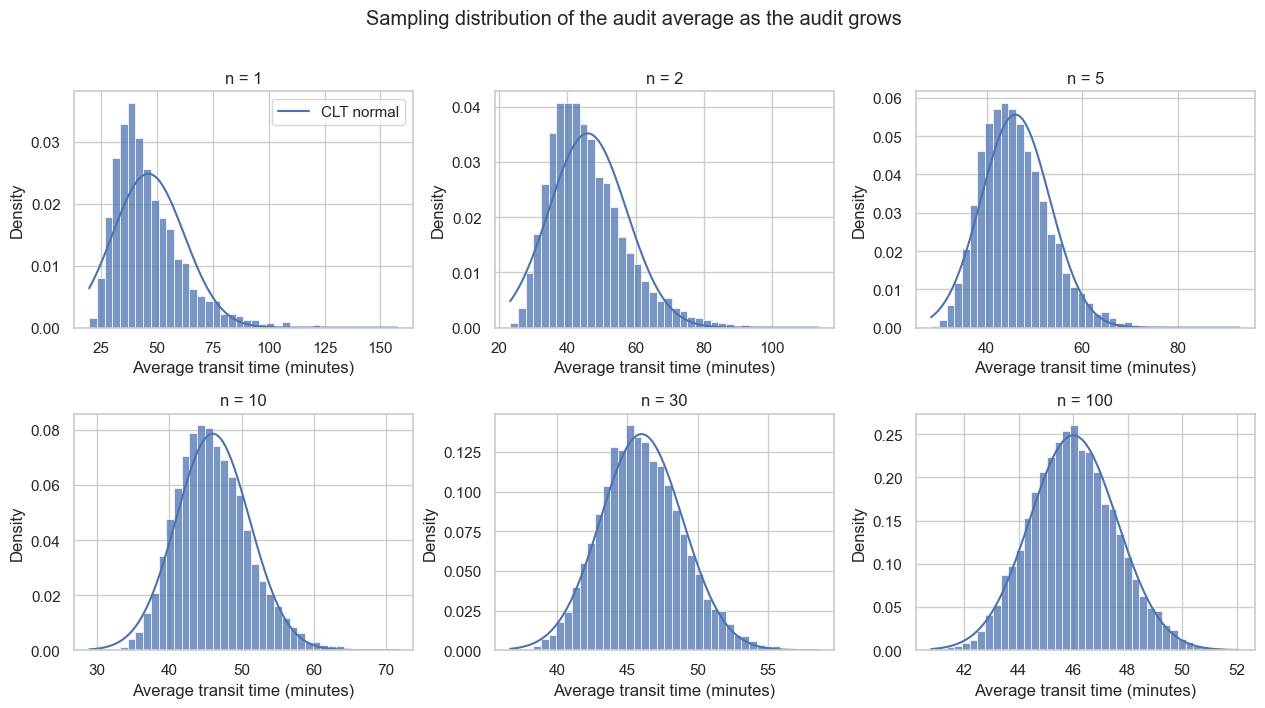

In [12]:
# Simulate the sampling distribution of the audit average for six audit sizes
sizes = [1, 2, 5, 10, 30, 100]
B = 10_000
rng = np.random.default_rng(207)
sim = {m: rng.choice(times, size=(B, m), replace=True).mean(axis=1) for m in sizes}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, m in zip(axes.ravel(), sizes):
    sns.histplot(sim[m], bins=40, stat="density", ax=ax)
    grid = np.linspace(sim[m].min(), sim[m].max(), 300)
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma / np.sqrt(m)), label="CLT normal")
    ax.set_title(f"n = {m}")
    ax.set_xlabel("Average transit time (minutes)")
axes[0, 0].legend()
plt.suptitle("Sampling distribution of the audit average as the audit grows", y=1.01)
plt.tight_layout()
plt.show()

  n   mean     SD  theory_SE  skew  theory_skew  KS_distance
  1 46.352 16.251     16.045 1.634        1.630        0.099
  2 46.045 11.373     11.346 1.097        1.153        0.074
  5 45.949  7.137      7.176 0.730        0.729        0.052
 10 46.001  5.068      5.074 0.525        0.515        0.039
 30 46.014  2.939      2.929 0.301        0.298        0.024
100 46.004  1.596      1.605 0.192        0.163        0.018


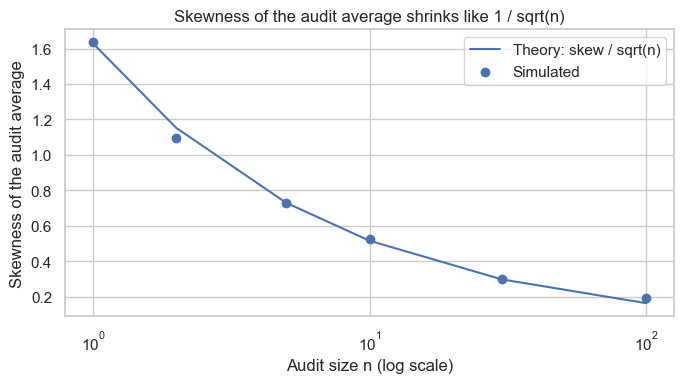

In [13]:
# Quantify the convergence: center, spread, skewness, and distance from normality
skew_pop = stats.skew(times)
rows = []
for m in sizes:
    x = sim[m]
    z_std = (x - mu) / (sigma / np.sqrt(m))
    rows.append({
        "n": m,
        "mean": x.mean(),
        "SD": x.std(),
        "theory_SE": sigma / np.sqrt(m),
        "skew": stats.skew(x),
        "theory_skew": skew_pop / np.sqrt(m),
        "KS_distance": stats.kstest(z_std, "norm").statistic,
    })
convergence = pd.DataFrame(rows)
print(convergence.to_string(index=False, float_format="{:.3f}".format))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(convergence["n"], convergence["theory_skew"], label="Theory: skew / sqrt(n)")
ax.scatter(convergence["n"], convergence["skew"], label="Simulated", zorder=3)
ax.set_xscale("log")
ax.set_xlabel("Audit size n (log scale)")
ax.set_ylabel("Skewness of the audit average")
ax.set_title("Skewness of the audit average shrinks like 1 / sqrt(n)")
ax.legend()
plt.tight_layout()
plt.show()

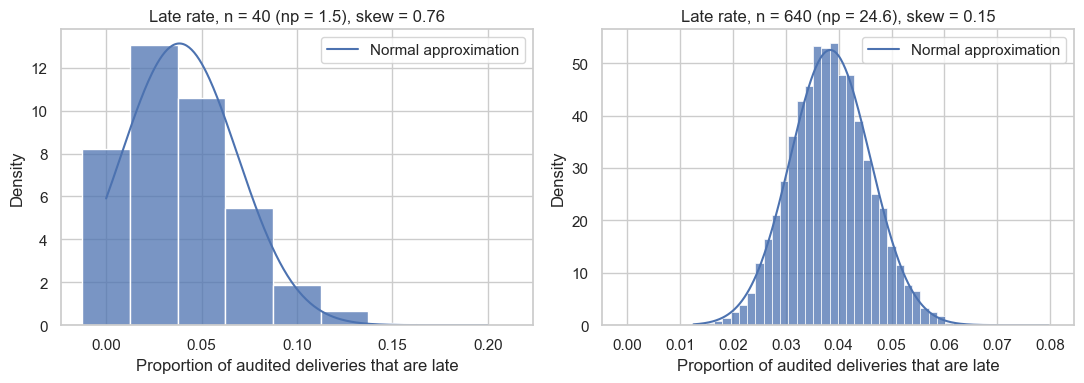

In [14]:
# The same experiment for the late rate: audit sizes 40 and 640
rng = np.random.default_rng(207)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m in zip(axes, [40, 640]):
    counts = rng.binomial(m, p_late, size=10_000)
    phat = counts / m
    bins = np.arange(-0.5, counts.max() + 1.5) / m
    sns.histplot(phat, bins=bins, stat="density", ax=ax)
    grid = np.linspace(phat.min(), phat.max(), 300)
    ax.plot(grid, stats.norm.pdf(grid, p_late, np.sqrt(p_late * (1 - p_late) / m)), label="Normal approximation")
    ax.set_title(f"Late rate, n = {m} (np = {m * p_late:.1f}), skew = {stats.skew(phat):.2f}")
    ax.set_xlabel("Proportion of audited deliveries that are late")
    ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Sample size for a +/- 3 minute margin of error at 95% confidence
target_moe = 3
n_needed = int(np.ceil((1.96 * sigma / target_moe) ** 2))

rng = np.random.default_rng(207)
means_needed = rng.choice(times, size=(10_000, n_needed), replace=True).mean(axis=1)
within = (np.abs(means_needed - mu) <= target_moe).mean()

print(f"Required audit size: n = {n_needed}")
print(f"Share of simulated audits within +/- {target_moe} minutes of the true mean: {within:.4f}")

# Monte Carlo precision of a simulated probability with B = 10,000 runs
mc_se = np.sqrt(p_clt * (1 - p_clt) / 10_000)
print(f"Monte Carlo standard error for a probability near {p_clt:.3f}: {mc_se:.4f}")

# Margin of error at the current audit size versus the recommended size
for m in [40, n_needed]:
    print(f"n = {m:>3}: 95% margin of error = {1.96 * sigma / np.sqrt(m):.2f} minutes")

Required audit size: n = 110
Share of simulated audits within +/- 3 minutes of the true mean: 0.9508
Monte Carlo standard error for a probability near 0.058: 0.0023
n =  40: 95% margin of error = 4.97 minutes
n = 110: 95% margin of error = 3.00 minutes


**Reading the results.** The histograms move from the skewed shape of single deliveries ($n = 1$) to a narrow, symmetric bell by $n = 30$ to $n = 100$, with the CLT curve tracking the simulation more closely at each step. In the table the mean stays fixed at 46.01 while the standard deviation follows $\sigma/\sqrt{n}$ exactly, the simulated skewness follows $\text{skew}/\sqrt{n}$, and the Kolmogorov–Smirnov distance to the normal falls from 0.099 at $n = 1$ to 0.018 at $n = 100$. The late-rate panels tell the same story: at $n = 40$ the distribution is lumpy and skewed, while at $n = 640$ it is smooth and bell-shaped.

The sample-size check succeeds: with $n =$ 110 deliveries, 95.1% of simulated audits land within ±3 minutes of the true mean, close to the intended 95%.

## Business Application

The simulation turns the CLT from a claim into evidence Liza can put in front of clients and the finance team, and it produces a concrete recommendation.

- **Audit size.** At the current 40 deliveries a week, the 95% margin of error on the reported average is ±5.0 minutes. Raising the audit to 110 deliveries tightens it to ±3 minutes. The Operations Director can decide whether the added inspection time is worth a reported average that a client can rely on to within three minutes.
- **Alternative to a bigger weekly audit.** Pooling three consecutive weekly audits of 40 gives 120 deliveries and reaches nearly the same precision without changing the weekly workload, provided service is stable across those weeks.
- **Client reporting.** The simulation output and the QQ plots are ready-made exhibits for a client review: they show that the margin of error is not an assumption about bell-shaped data but a result checked against the company's own delivery history.

## Key Takeaways

**Random variables and distributions**

- A random variable assigns a number to each outcome; discrete variables are counted (pmf), continuous variables are measured (pdf, probability as area).
- Binomial: fixed $n$, two outcomes, constant $p$, independent trials; $P(K=k)=\binom{n}{k}p^k(1-p)^{n-k}$.
- Normal: standardize with $z=(x-\mu)/\sigma$; temperature is bell-shaped, transit time is right-skewed.

**Expectation and variance**

- $E[X]=\sum x\,p(x)$; $\operatorname{Var}(X)=E[X^2]-(E[X])^2$; SD returns spread to original units.
- $E[aX+b]=aE[X]+b$ and $\operatorname{Var}(aX+b)=a^2\operatorname{Var}(X)$; for independent sums, means add and variances add.
- Binomial: $E[K]=np$, $\operatorname{Var}(K)=np(1-p)$; the mean sets the provision, the variance sizes the reserve.

**Sampling distributions**

- A statistic is a random variable; its distribution across repeated samples is the sampling distribution.
- $E[\bar{X}]=\mu$ and $\operatorname{SE}(\bar{X})=\sigma/\sqrt{n}$; quadruple $n$ to halve the SE.
- $\operatorname{SE}(\hat{p})=\sqrt{p(1-p)/n}$; finite-population correction is negligible when $n \ll N$.

**Central Limit Theorem**

- $\bar{X}\approx N(\mu,\sigma^2/n)$ for iid data with finite variance, regardless of the data's shape.
- Skewed data need larger $n$; skewness of $\bar{X}$ falls like $1/\sqrt{n}$.
- Proportions need $np\ge 10$ and $n(1-p)\ge 10$; below that, use the exact binomial.

**Simulating the CLT**

- Simulation draws many samples to reveal the sampling distribution directly; Monte Carlo SE is $\sqrt{P(1-P)/B}$.
- Required audit size for margin of error $E$: $n \ge (1.96\,\sigma/E)^2$.
- Verify formulas against simulation before relying on them for decisions.

## References

Berry, A. C. (1941). The accuracy of the Gaussian approximation to the sum of independent variates. *Transactions of the American Mathematical Society, 49*(1), 122–136.

Blitzstein, J. K., & Hwang, J. (2019). *Introduction to probability* (2nd ed.). CRC Press.

Casella, G., & Berger, R. L. (2002). *Statistical inference* (2nd ed.). Duxbury.

Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., ... Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*, 357–362.

Ross, S. M. (2019). *A first course in probability* (10th ed.). Pearson.

Virtanen, P., Gommers, R., Oliphant, T. E., Haberland, M., Reddy, T., Cournapeau, D., ... SciPy 1.0 Contributors. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*, 261–272.

Wasserman, L. (2004). *All of statistics: A concise course in statistical inference*. Springer.